# **Preparacion de datos para el modelo IA Prediccion de Abandono para los clientes *(CHURN)***



## **Configuración inicial y carga de datos**
**Cargar los datos desde archivos CSV** \
Los siguientes archivos contienen los datos necesarios para preparar el modelo de predicción:
- Customers_Data.csv: Información principal de los clientes.
- Interaction_Types_Data.csv: Tipos de interacciones posibles.
- Customer_Activity_Data.csv: Registro de actividades de los clientes.

> si hay problemas con los dataset usar los de la carpeta /DataSets en logar de los links de drive

In [29]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# DataSets Cargados publicamente desde drive
customers_url = "https://drive.google.com/uc?id=1KbGDXj8ruGIfJZ7iviui0DhKbrhJnttj"
activity_types_url = "https://drive.google.com/uc?id=1gfx_JV2kZO4iNJ-owLLCUnYGRIJNN7w_"
customer_activity_url = "https://drive.google.com/uc?id=1ScmOSmc_4UHor78kdS0F7Y1PHRtOL9F4"

# Leer los archivos desde las URLs
customers_df = pd.read_csv(customers_url)
activity_types_df = pd.read_csv(activity_types_url)
customer_activity_df = pd.read_csv(customer_activity_url)

Empezamos revisando los tipos de datos para detectar valores nulos

In [30]:
# Este paso verifica las columnas, sus tipos y si hay valores faltantes en los datos.

print(f"Inspeccionar tipos de datos \n", customers_df.dtypes, "\n")
print(f"\n Detectar valores nulos \n", customers_df.isnull().sum())

print(f"\n Inspeccionar tipos de datos \n", customer_activity_df.dtypes, "\n")
print(f"\n Detectar valores nulos \n", customer_activity_df.isnull().sum())

Inspeccionar tipos de datos 
 id                       int64
name                    object
registration_date       object
last_purchase_date      object
average_order_value    float64
total_purchases          int64
churn_status             int64
dtype: object 


 Detectar valores nulos 
 id                     0
name                   0
registration_date      0
last_purchase_date     0
average_order_value    0
total_purchases        0
churn_status           0
dtype: int64

 Inspeccionar tipos de datos 
 id                   int64
customer_id          int64
activity_type_id     int64
activity_date       object
dtype: object 


 Detectar valores nulos 
 id                  0
customer_id         0
activity_type_id    0
activity_date       0
dtype: int64


In [31]:
# Fechas con formato objet
# No hay valores nulos
from datetime import datetime

# Convertir columnas de fechas a datetime
customers_df['registration_date'] = pd.to_datetime(customers_df['registration_date'], errors='coerce')
customers_df['last_purchase_date'] = pd.to_datetime(customers_df['last_purchase_date'], errors='coerce')
customer_activity_df['activity_date'] = pd.to_datetime(customer_activity_df['activity_date'], errors='coerce')

# Validar los cambios
print(customers_df.dtypes)
print("\n", customer_activity_df.dtypes)

id                              int64
name                           object
registration_date      datetime64[ns]
last_purchase_date     datetime64[ns]
average_order_value           float64
total_purchases                 int64
churn_status                    int64
dtype: object

 id                           int64
customer_id                  int64
activity_type_id             int64
activity_date       datetime64[ns]
dtype: object


## Generar características requeridas para el modelo
Construimos cada columna requerida para el modelo a partir de los datos disponibles, recordemos que los datos para el modelo son los siguientes:

*   tiempo_desde_ultima_compra: Diferencia en días desde la ultima compra
*   frecuencia_compra: Número total de compras dividido por el tiempo como cliente.
*   actividad_reciente: Número de interacciones en los últimos 90 días.
*   total_interacciones: Total de interacciones del cliente.
*   promedio_mensual_compras: Total de compras dividido por la cantidad de meses como cliente.
*   churn: etiqueta de clientes marcados como perdidos.


## **Tiempo desde la última compra (time_since_last_purchase)**

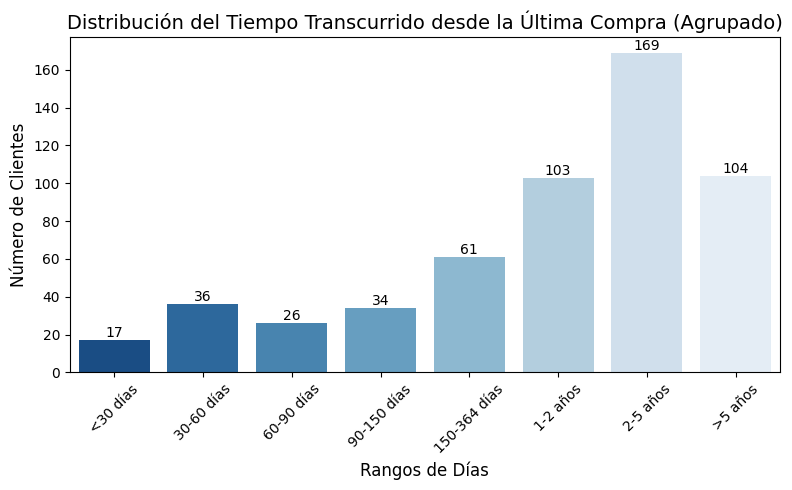

In [32]:
# Histograma para visualizar la distribución
import matplotlib.pyplot as plt # fundamental para crear gráficos en Python
import seaborn as sns # Ofrece gráficos estadísticos
import numpy as np

# Calcular tiempo desde la última compra
customers_df['time_since_last_purchase'] = (datetime.now() - customers_df['last_purchase_date']).dt.days

# Definir rangos de días para agrupar
bins = [0, 30, 60, 90, 150, 364, 730, 1825, 3650]
labels = ['<30 días', '30-60 días', '60-90 días', '90-150 días', '150-364 días', '1-2 años', '2-5 años', '>5 años']

# Crear una nueva columna categórica para los rangos
customers_df['time_since_last_purchase_group'] = pd.cut(
    customers_df['time_since_last_purchase'], bins=bins, labels=labels, right=False
)

# Contar la frecuencia de cada grupo
grouped_data = customers_df['time_since_last_purchase_group'].value_counts().sort_index()

# Graficar la distribución agrupada con solución al warning
plt.figure(figsize=(8, 5))
bars = sns.barplot(
    x=grouped_data.index,
    y=grouped_data.values,
    hue=grouped_data.index,  # Solución al warning
    palette="Blues_r",
    dodge=False
)

# Mostrar valores encima de las barras
for bar, value in zip(bars.patches, grouped_data.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Posición horizontal
        bar.get_height(),  # Altura de la barra
        f"{value}",  # Valor
        ha='center', va='bottom', fontsize=10  # Centrado y pequeño
    )

# Etiquetas y título
plt.title('Distribución del Tiempo Transcurrido desde la Última Compra (Agrupado)', fontsize=14)
plt.xlabel('Rangos de Días', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.xticks(rotation=45, fontsize=10)  # Rotación para claridad
plt.legend([],[], frameon=False)  # Opcional: Ocultar leyenda si no es necesaria
plt.tight_layout()
plt.show()

El grafico nos ayuda a identificar que no hay fechas atopicas de la columna *last_purchase_date*







## **Frecuencia de compra (purchase_frequency)**
Fórmula:
Frecuencia = Total de Compras / Tiempo como clientes *(en meses)*

Este cálculo es una tasa que mide el número de compras por mes y se interpreta como cuántas compras realiza un cliente por unidad de tiempo.

In [33]:
# Calcular tiempo vida del cliente (en días)
customers_df['days_as_customer'] = (datetime.now() - customers_df['registration_date']).dt.days
# Calcular frecuencia de compra
customers_df['purchase_frequency'] = customers_df['total_purchases'] / (customers_df['days_as_customer']/30)
# Resumen estadístico
print(customers_df['purchase_frequency'].describe())

count    550.000000
mean       1.280001
std        4.375109
min        0.000000
25%        0.185306
50%        0.396081
75%        0.778800
max       60.000000
Name: purchase_frequency, dtype: float64


## **Actividad reciente (recent_activity)**

In [34]:
# Filtrar actividades en los últimos 90 días
recent_cutoff = datetime.now() - pd.Timedelta(days=90)
recent_activity = customer_activity_df[customer_activity_df['activity_date'] >= recent_cutoff]
# Contar actividades recientes por cliente
recent_activity_counts = recent_activity.groupby('customer_id').size()
# Si es no tiene actividades se remplaza por 0
customers_df['recent_activity'] = customers_df['id'].map(recent_activity_counts).fillna(0)
# Resumen estadístico
print(customers_df['recent_activity'].describe())

count    550.000000
mean       2.816364
std        3.032445
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       23.000000
Name: recent_activity, dtype: float64


## **Total de interacciones (total_interactions)**

In [35]:
# Contar todas las interacciones por cliente
total_activity_counts = customer_activity_df.groupby('customer_id').size()
customers_df['total_interactions'] = customers_df['id'].map(total_activity_counts).fillna(0)
# Resumen estadístico
print(customers_df['total_interactions'].describe())

count    550.000000
mean      46.630909
std       31.237677
min        1.000000
25%       16.250000
50%       48.000000
75%       74.000000
max      100.000000
Name: total_interactions, dtype: float64


## **Promedio mensual de compras (monthly_avg_purchases)**

Similar a *purchase_frequency (Frecuencia de Compra)*, pero \
No mide la frecuencia de actividad en función del tiempo, sino un valor absoluto promedio de compras realizado en cada mes.


In [36]:
# Calcular promedio mensual de compras
customers_df['monthly_avg_purchases'] = customers_df['total_purchases'] / (customers_df['days_as_customer'] / 30)

# Resumen estadístico
print(customers_df['monthly_avg_purchases'].describe())

count    550.000000
mean       1.280001
std        4.375109
min        0.000000
25%        0.185306
50%        0.396081
75%        0.778800
max       60.000000
Name: monthly_avg_purchases, dtype: float64


In [37]:
# Ya calculado como churn_status en los datos iniciales
customers_df['churn'] = customers_df['churn_status']
print(customers_df['churn'].value_counts())


churn
1    459
0     91
Name: count, dtype: int64


## **Cambio de divisa en:** *avarege_order_value*
Contamos con los datos necesarios pero hace falta comvertir los valores de ('average_order_value', Valor promedio de compra) que estan en Dolare USD a la moneda colombiana

>⚠️ No ejecutar mas de 1 vez el codigo o los datos se veran afectado

In [38]:
# Tipo de cambio de USD a COP
usd_to_cop_rate = 4200

# Convertir la columna 'average_order_value' de USD a COP
customers_df['average_order_value'] = customers_df['average_order_value'] * usd_to_cop_rate
# Mostrar los primeros valores para verificar
print(customers_df['average_order_value'].head())

0    134442.0
1    365316.0
2    188265.0
3    148092.0
4    110279.4
Name: average_order_value, dtype: float64


## **Agrupar las columnas en un conjunto de datos relevantes para el modelo de predicción**
Este paso filtra las columnas necesarias, eliminando las que no aportan al análisis o modelo


In [39]:
# Seleccionar las columnas relevantes para el modelo de prediccion
prepared_data = customers_df[[
    'id',                     # ID del cliente
    'time_since_last_purchase', # Tiempo desde la última compra
    'purchase_frequency',       # Frecuencia de compra
    'average_order_value',      # Valor promedio de compra
    'total_purchases',          # Total de compras
    'recent_activity',          # Actividad reciente (90 días)
    'total_interactions',       # Total de interacciones
    'monthly_avg_purchases',    # Promedio mensual de compras
    'churn'                     # Churn (0 o 1)
]]
print(f"Primeras 5 filas \n", prepared_data.head())
print(prepared_data.isnull().sum())


# Exportar el conjunto de datos preparado a un archivo CSV
prepared_data.to_csv('data_export_churn_service.csv', index=False)

Primeras 5 filas 
    id  time_since_last_purchase  purchase_frequency  average_order_value  \
0   1                       829            0.482498             134442.0   
1   2                      1759            0.067340             365316.0   
2   3                       147            0.165746             188265.0   
3   4                       394            0.119237             148092.0   
4   5                      1829            0.010787             110279.4   

   total_purchases  recent_activity  total_interactions  \
0               17              3.0                  48   
1                6              5.0                  92   
2                5              3.0                  84   
3                5              2.0                  37   
4                1              2.0                  51   

   monthly_avg_purchases  churn  
0               0.482498      1  
1               0.067340      1  
2               0.165746      1  
3               0.119237      1  

## Exportar el  conjunto de datos para el modelo de prediccion en Google Colab:
>Solo si lo requieres

In [143]:
# Solo si se ejecuta en Google Colab
from google.colab import files
files.download('data_export_churn_service.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>